### Expectation Maximization Algorithm
#### https://www.geeksforgeeks.org/machine-learning/ml-expectation-maximization-algorithm/

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

#### Step 2 : Generate a dataset with two Gaussian components

In [3]:
''' We generate two sets of data values from two different normal distributions:
One centered around 2 (with more spread).
Another around -1 (with less spread).
These two sets are then combined to form a single dataset. We plot this dataset to visualize how the values are distributed'''

' We generate two sets of data values from two different normal distributions:\nOne centered around 2 (with more spread).\nAnother around -1 (with less spread).\nThese two sets are then combined to form a single dataset. We plot this dataset to visualize how the values are distributed'

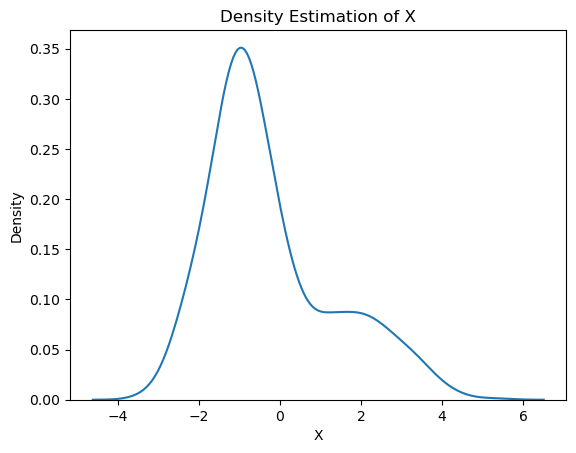

In [4]:
mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8

X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

#### Step 3: Initialize parameters

##### We make initial guesses for each group’s:

* Mean (average),
* Standard deviation (spread),
* Proportion (how much each group contributes to the total data).

In [5]:
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)
print(f"mu1: {mu1_hat}, sigma1: {sigma1_hat}, mu2: {mu2_hat}, sigma2: {sigma2_hat}")
print(pi1_hat, pi2_hat)

mu1: 2.0061873808854624, sigma1: 1.0584730407089413, mu2: -1.0063895278914223, sigma2: 0.7760415187407912
0.25 0.75


#### Step 4: Perform EM algorithm

##### We run a loop for 20 rounds called epochs. In each round:

* The E-step calculates the responsibilities (gamma values) by evaluating the Gaussian probability densities for each component and weighting them by the corresponding proportions.
* The M-step updates the parameters by computing the weighted mean and standard deviation for each component

* We also calculate the log-likelihood in each round to check if the model is getting better. This is a measure of how well the model explains the data.

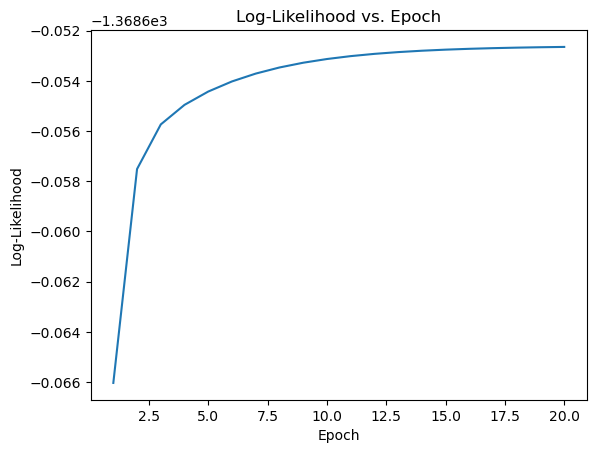

In [6]:
num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2
    gamma1 /= total
    gamma2 /= total

    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat)**2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat)**2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)

    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
                                   + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)


plt.plot(range(1, num_epochs + 1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()

#### Step 5: Visualize the Final Result

* Now we will finally visualize the curve which compare the final estimated curve (in red) with the original data’s smooth curve (in green).

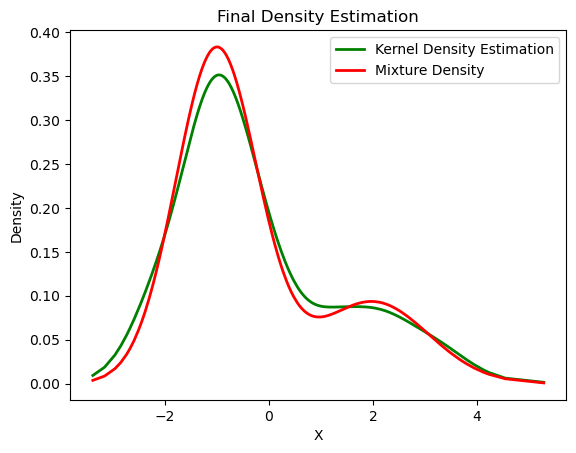

In [7]:
X_sorted = np.sort(X)
density_estimation = (pi1_hat * norm.pdf(X_sorted, mu1_hat, sigma1_hat) +
                      pi2_hat * norm.pdf(X_sorted, mu2_hat, sigma2_hat))

plt.plot(X_sorted, gaussian_kde(X_sorted)(
    X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Final Density Estimation')
plt.legend(['Kernel Density Estimation', 'Mixture Density'])
plt.show()